# Taller SVM — Aplicación a Bank Marketing (bank-full.csv)

**Curso:** Aprendizaje Supervisado — C3 Taller 1 ("Entrenamiento y Evaluación de un Modelo SVM")
**Sector:** Marketing bancario / retención de clientes — predecir si un cliente suscribe un depósito a plazo.


Se mantienen las decisiones ya validadas en tallers anteriores:
- Se elimina `duration` por fuga de información (data leakage).
- `pdays = -1` es un valor centinela (sin contacto previo), no una magnitud real.
- Las categorías `"unknown"` se tratan como una categoría más (no como nulos).
- Desbalance de clases ~88/12 → se usa `class_weight='balanced'`, *split* estratificado y métricas más allá de accuracy.

In [ ]:
import pandas as pd, numpy as np, json, time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, precision_recall_curve,
                              average_precision_score, classification_report)

RANDOM_STATE = 42
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

## 1. Carga y preprocesamiento

In [ ]:
df = pd.read_csv('bank-full.csv', sep=';')
df = df.drop(columns=['duration'])

y = (df['y'] == 'yes').astype(int)
X_raw = df.drop(columns=['y'])
X = pd.get_dummies(X_raw, drop_first=True)
feat_names = list(X.columns)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr)
Xte_scaled = scaler.transform(Xte)

print("Dimensión total (con one-hot):", X.shape)
print("Train:", Xtr.shape, " Test:", Xte.shape)
print("Balance de clases (train):", ytr.value_counts(normalize=True).round(3).to_dict())

Dimensión total (con one-hot): (45211, 41)
Train: (36168, 41)  Test: (9043, 41)
Balance de clases (train): {0: 0.883, 1: 0.117}


### Submuestra para la etapa de ajuste de hiperparámetros

se usa una **submuestra estratificada de 8,000 obseraciones** del set de entrenamiento para toda la fase de exploración de hiperparámetros. El **modelo final se evalúa siempre sobre el set de test completo (9,043 filas), que nunca se toca durante el ajuste.**

In [ ]:
N_SUB = 8000
sub_idx, _ = train_test_split(np.arange(len(Xtr_scaled)), train_size=N_SUB,
                               stratify=ytr, random_state=RANDOM_STATE)
Xsub, ysub = Xtr_scaled[sub_idx], ytr.iloc[sub_idx].reset_index(drop=True)

print("Submuestra de ajuste:", Xsub.shape)
print("Balance en la submuestra:", ysub.value_counts(normalize=True).round(3).to_dict())

def eval_model(model, Xte_, yte_):
    pred = model.predict(Xte_)
    return {
        'accuracy': accuracy_score(yte_, pred),
        'precision': precision_score(yte_, pred, zero_division=0),
        'recall': recall_score(yte_, pred, zero_division=0),
        'f1': f1_score(yte_, pred, zero_division=0),
    }

Submuestra de ajuste: (8000, 41)
Balance en la submuestra: {0: 0.883, 1: 0.117}


## 2. ¿Qué es SVM?

Una **Máquina de Vectores de Soporte (SVM)** busca el hiperplano que separa las clases maximizando el **margen** (la distancia entre el hiperplano y los puntos más cercanos de cada clase, llamados **vectores de soporte**).

- **C**: equilibrio entre margen ancho y errores de clasificación. Alto → rígido (riesgo de sobreajuste). Bajo → flexible (riesgo de subajuste).
- **Kernel**: transforma el espacio para separar datos no lineales (`linear`, `poly`, `rbf`, `sigmoid`).
- **Gamma** (`rbf`/`poly`/`sigmoid`): alcance de influencia de cada punto. Bajo → influencia amplia. Alto → influencia local (riesgo de sobreajuste).
- **degree** (`poly`): grado del polinomio — a mayor grado, fronteras más curvas y más sensibles al ruido.
- **coef0** (`poly`/`sigmoid`): desplaza el peso relativo entre términos de bajo y alto grado.

## 3. Punto 1 — Kernels y combinaciones de hiperparámetros

### 3.1 Modelo base

In [ ]:
base_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE)
base_model.fit(Xsub, ysub)
base_metrics = eval_model(base_model, Xte_scaled, yte)
pd.DataFrame([base_metrics])

,accuracy,precision,recall,f1
0,0.823289,0.343023,0.557656,0.424766


- Exactitud (Accuracy): El modelo acierta en la gran mayoría de las predicciones globales.
- Precisión (para la clase "Sí"): De todos los casos que el modelo predijo como Sí, solo un tercio eran realmente correctos (alto índice de falsas alarmas).
- Sensibilidad / Recall (para la clase "Sí"): El modelo logra capturar algo más de la mitad de los casos positivos reales, dejando un $44,3\%$ de casos reales de clase Sí sin detectar (falsos negativos).
- F1-Score (para la clase "Sí"): Indica un rendimiento general bajo a moderado para la clase minoritaria; al penalizar los desequilibrios extremos, refleja que el modelo sufre simultáneamente de un alto índice de falsas alarmas (baja precisión) y de una cantidad considerable de casos reales que no logra detectar (recall moderado).

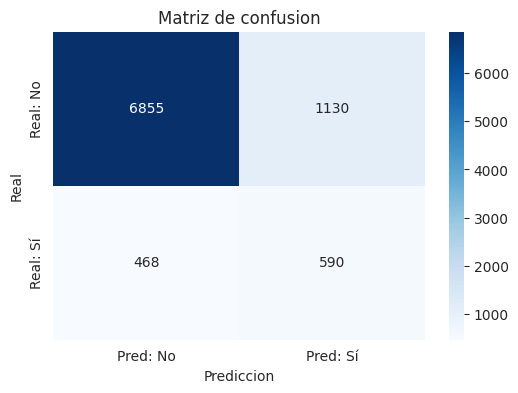

In [ ]:
y_pred_base = base_model.predict(Xte_scaled)
cm_base = confusion_matrix(yte, y_pred_base)

plt.figure(figsize=(6,4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No','Pred: Sí'], yticklabels=['Real: No','Real: Sí'])
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de confusion')
plt.show()

# Desglose de Valores

- Verdaderos Negativos (TN): $6.855$ casos en los que el valor real era No y el modelo predijo correctamente No.   
- Falsos Positivos (FP): $1.130$ casos en los que el valor real era No, pero el modelo predijo incorrectamente Sí.   
- Falsos Negativos (FN): $468$ casos en los que el valor real era Sí, pero el modelo predijo incorrectamente No.   
- Verdaderos Positivos (TP): $590$ casos en los que el valor real era Sí y el modelo predijo correctamente Sí.   

### 3.2 Barrido manual de C (kernel=rbf, gamma=scale)

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]
c_results = []
for c in C_values:
    m = SVC(kernel='rbf', C=c, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE)
    m.fit(Xsub, ysub)
    met = eval_model(m, Xte_scaled, yte)
    met['C'] = c
    c_results.append(met)

c_df = pd.DataFrame(c_results)[['C','accuracy','precision','recall','f1']]
best_C = c_df.loc[c_df['f1'].idxmax(), 'C']
c_df

,C,accuracy,precision,recall,f1
0,0.01,0.711821,0.222581,0.586957,0.322765
1,0.10,0.804711,0.317337,0.581285,0.410547
2,1.00,0.823289,0.343023,0.557656,0.424766
3,10.00,0.804047,0.275754,0.414934,0.331321
4,100.00,0.800288,0.249665,0.352552,0.292320


# Análisis por Valores del Parámetro $C$
- $C = 0.01$ (Bajo, alta regularización):El modelo prioriza fuertemente la simplicidad de la frontera de decisión para evitar el sobreajuste.
  - Presenta la exactitud global más baja ($71,2\%$) y la precisión más baja ($22,3\%$), lo que indica que comete muchos falsos positivos (muchas falsas alarmas). Sin embargo, logra un recall alto ($58,7\%$), capturando la mayor cantidad de casos reales positivos de toda la prueba.

- $C = 0.1$ y $C = 1.0$ (Zona de equilibrio óptimo):Al aumentar $C$, el modelo gana flexibilidad para ajustarse mejor a los datos.
  - En $C = 1.0$ se alcanza el punto de mejor rendimiento general: la exactitud llega a su pico máximo ($82,3\%$), la precisión sube a su valor más alto ($34,3\%$) y el F1-score alcanza el valor óptimo de $0,425$ ($42,5\%$). Aunque el recall disminuye ligeramente ($55,8\%$), el balance entre precisión y falsos negativos es el más adecuado.  

- $C = 10.0$ y $C = 100.0$ (Alto, menor regularización / sobreajuste potencial):Valores muy altos de $C$ penalizan severamente los errores de clasificación en el conjunto de entrenamiento, forzando una frontera de decisión muy compleja o rígida.
  - Se observa una caída drástica en el recall (que desciende hasta el $29,2\%$ cuando $C=100$) y una disminución general del F1-score (hasta $0,292$). El modelo se vuelve demasiado estricto o rígido al predecir la clase positiva, dejando escapar a la gran mayoría de los casos reales (muchos falsos negativos).

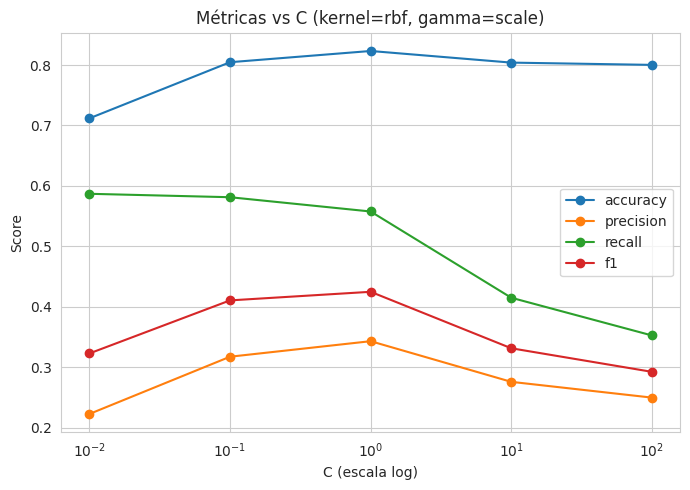

Mejor C según F1: 1.0


In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
for col in ['accuracy','precision','recall','f1']:
    ax.plot(c_df['C'], c_df[col], marker='o', label=col)
ax.set_xscale('log')
ax.set_xlabel('C (escala log)'); ax.set_ylabel('Score')
ax.set_title('Métricas vs C (kernel=rbf, gamma=scale)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mejor C según F1: {best_C}")

**Interpretación:** el F1 sube de C=0.01 a C=1 y cae en C=10 y C=100 — con C alto el modelo se sobreajusta a la submuestra y pierde recall en test. **C=1 da el mejor equilibrio.**

### 3.3 Barrido manual de gamma (con el mejor C)

In [ ]:
gamma_values = [0.001, 0.01, 0.1, 1, 'scale']
g_results = []
for g in gamma_values:
    m = SVC(kernel='rbf', C=best_C, gamma=g, class_weight='balanced', random_state=RANDOM_STATE)
    m.fit(Xsub, ysub)
    met = eval_model(m, Xte_scaled, yte)
    met['gamma'] = str(g)
    g_results.append(met)

g_df = pd.DataFrame(g_results)[['gamma','accuracy','precision','recall','f1']]
best_gamma_str = g_df.loc[g_df['f1'].idxmax(), 'gamma']
best_gamma = best_gamma_str if best_gamma_str in ('scale','auto') else float(best_gamma_str)
g_df

,gamma,accuracy,precision,recall,f1
0,0.001,0.824726,0.340593,0.532136,0.415345
1,0.01,0.827159,0.353283,0.574669,0.437567
2,0.1,0.810240,0.259151,0.334594,0.292079
3,1,0.849386,0.138095,0.054820,0.078484
4,scale,0.823289,0.343023,0.557656,0.424766


# Análisis por Valores del Parámetro

- $\gamma = 0.001$ y $\gamma = 0.01$ (Bajo/Moderado - Frontera Suave):Con valores bajos, la influencia de cada vector de soporte es amplia, generando una frontera de decisión suave y más general.
  - En $\gamma = 0.01$ se logra el mejor rendimiento global para la clase minoritaria: se alcanza el pico más alto de F1-score ($0,438$) y un excelente recall ($57,5\%$), manteniendo una exactitud global sólida de $82,7\%$. El valor por defecto scale (que equivale aproximadamente a $0.0009$ dependiendo de las características) ofrece un comportamiento muy similar y competitivo.   

- $\gamma = 0.1$ (Comienza el deterioro):Al aumentar $\gamma$, el radio de influencia de cada punto se reduce, haciendo que la frontera empiece a curvarse de forma más ajustada.
  - Se registra una caída notable en el recall ($33,5\%$) y en el F1-score ($0,292$), lo que indica que el modelo empieza a perder capacidad para detectar correctamente los casos positivos reales.  

- $\gamma = 1$ (Alto - Sobreajuste / Overfitting severo):Un gamma alto crea islas o regiones de decisión cerradas y muy complejas alrededor de puntos individuales en el conjunto de entrenamiento.
  - Aunque la exactitud global parece engañosamente alta ($84,9\%$) debido a que el modelo acierta abrumadoramente en la clase mayoritaria "No", el rendimiento en la clase "Sí" se derrumba por completo: la precisión cae a $13,8\%$, el recall se desploma a un ínfimo $5,5\%$ y el F1-score se hunde hasta $0,078$. El modelo se vuelve hiper-específico y es incapaz de generalizar adecuadamente para los positivos.

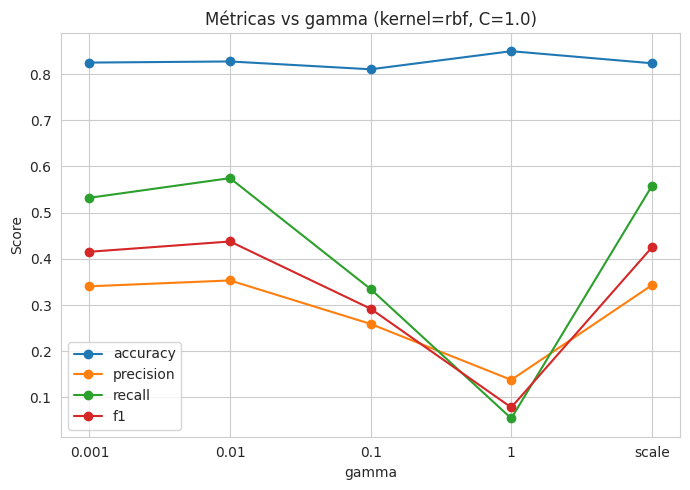

Mejor gamma según F1: 0.01


In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
x_pos = np.arange(len(g_df))
for col in ['accuracy','precision','recall','f1']:
    ax.plot(x_pos, g_df[col], marker='o', label=col)
ax.set_xticks(x_pos); ax.set_xticklabels(g_df['gamma'])
ax.set_xlabel('gamma'); ax.set_ylabel('Score')
ax.set_title(f'Métricas vs gamma (kernel=rbf, C={best_C})')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mejor gamma según F1: {best_gamma}")

**Interpretación:** gamma=1 colapsa el recall (0.05, sobreajuste extremo: el modelo se vuelve demasiado local). **gamma=0.01 da el mejor F1**, superando incluso a `'scale'`.

El parámetro $\gamma$ define qué tan complejo o localizado es el ajuste del núcleo RBF. En este problema, un gamma bajo ($\gamma = 0.01$) o la opción por defecto (scale) proporcionan el mejor equilibrio, permitiendo capturar de manera óptima los casos positivos. Por el contrario, un gamma elevado ($\gamma = 1$) sobreajusta el modelo de forma extrema, arruinando por completo su capacidad de detección para la clase minoritaria a pesar de mostrar una falsa sensación de mejora en la exactitud global.  

### 3.4 Comparación de kernels (linear, poly, rbf, sigmoid)

In [ ]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
k_results = []
for k in kernels:
    kwargs = dict(kernel=k, C=best_C, class_weight='balanced', random_state=RANDOM_STATE)
    if k != 'linear':
        kwargs['gamma'] = best_gamma
    m = SVC(**kwargs)
    m.fit(Xsub, ysub)
    met = eval_model(m, Xte_scaled, yte)
    met['kernel'] = k
    k_results.append(met)

k_df = pd.DataFrame(k_results)[['kernel','accuracy','precision','recall','f1']]
best_kernel = k_df.loc[k_df['f1'].idxmax(), 'kernel']
k_df

,kernel,accuracy,precision,recall,f1
0,linear,0.796417,0.297883,0.545369,0.385309
1,poly,0.868075,0.433888,0.418715,0.426166
2,rbf,0.827159,0.353283,0.574669,0.437567
3,sigmoid,0.759261,0.258315,0.565217,0.354580


# Análisis por Tipo de Kernel

- linear (Lineal):Traza una frontera recta para separar las clases.
  - Obtiene una exactitud global moderada ($79,6\%$) y un recall aceptable ($54,5\%$), pero su precisión es baja ($29,8\%$), lo que resulta en un F1-score de $0,385$. Esto indica que una línea recta es demasiado simple para capturar la complejidad real de los datos sin generar un exceso de falsas alarmas.

- poly (Polinomio):Utiliza una función polinómica para crear fronteras curvas más complejas.
  - Alcanza la exactitud global más alta de la comparativa ($86,8\%$) y la precisión más alta para la clase minoritaria ($43,4\%$). Sin embargo, su recall baja a $41,9\%$, obteniendo un F1-score de $0,426$. Es un modelo más estricto y preciso al dar una alerta positiva, pero deja escapar un mayor volumen de casos reales.

- rbf (Radial Basis Function - Gaussiano):Crea fronteras circulares o elípticas flexibles alrededor de los grupos de datos.
  - Demuestra el mejor equilibrio general para la clase minoritaria ("Sí"): alcanza el F1-score más alto ($0,438$) gracias al mejor recall ($57,5\%$) y una precisión competitiva de $35,3\%$, manteniendo además una excelente exactitud global ($82,7\%$). Es el kernel que mejor logra "descubrir" a los verdaderos positivos sin sacrificar excesivamente la tasa de aciertos.

- sigmoid (Sigmoide):Simula un comportamiento similar a una red neuronal de una capa con función logística.
  - Presenta el rendimiento global más bajo: la exactitud cae al $75,9\%$ y la precisión se desploma al $25,8\%$. Aunque mantiene un recall alto ($56,5\%$), su F1-score es pobre ($0,355$), lo que demuestra que este tipo de transformación no se adapta adecuadamente a la estructura de distribución de este conjunto de datos.

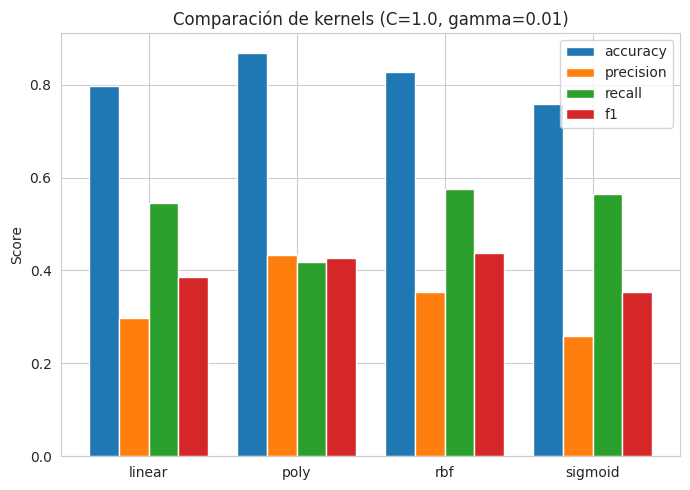

Mejor kernel según F1: rbf


In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
x = np.arange(len(k_df)); width = 0.2
for i, col in enumerate(['accuracy','precision','recall','f1']):
    ax.bar(x + i*width, k_df[col], width, label=col)
ax.set_xticks(x + 1.5*width); ax.set_xticklabels(k_df['kernel'])
ax.set_ylabel('Score'); ax.set_title(f'Comparación de kernels (C={best_C}, gamma={best_gamma})')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mejor kernel según F1: {best_kernel}")

**Interpretación:** La elección del kernel cambia radicalmente la forma en que el SVM interpreta el espacio de características. Mientras que el kernel poly destaca en precisión estricta y exactitud global, el kernel rbf se posiciona como la opción más equilibrada y robusta al maximizar el F1-score y la capacidad de detección (recall) para la clase positiva bajo estos hiperparámetros.

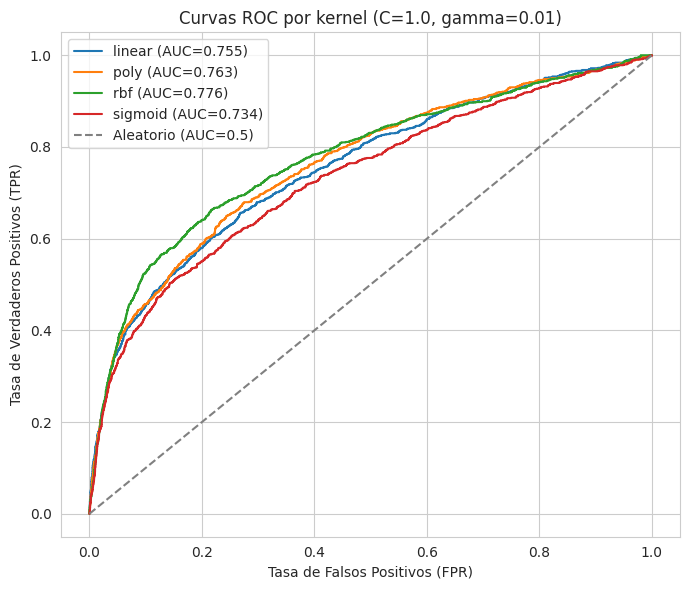

In [ ]:
kernel_rocs = {}
for k in kernels:
    kwargs = dict(kernel=k, C=best_C, class_weight='balanced', random_state=RANDOM_STATE)
    if k != 'linear':
        kwargs['gamma'] = best_gamma
    m = SVC(**kwargs)
    m.fit(Xsub, ysub)
    dec_k = m.decision_function(Xte_scaled)
    fpr_k, tpr_k, _ = roc_curve(yte, dec_k)
    kernel_rocs[k] = (fpr_k, tpr_k, auc(fpr_k, tpr_k))

fig, ax = plt.subplots(figsize=(7,6))
for k, (fpr_k, tpr_k, auc_k) in kernel_rocs.items():
    ax.plot(fpr_k, tpr_k, label=f'{k} (AUC={auc_k:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title(f'Curvas ROC por kernel (C={best_C}, gamma={best_gamma})')
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 ~15 combinaciones sistemáticas de C, gamma, degree y coef0

Los barridos anteriores variaron un hiperparámetro a la vez. Aquí se combinan de forma sistemática **C, gamma, degree y coef0 cruzados entre kernels**, verificar que el óptimo encontrado no dependa del orden en que se exploraron los hiperparámetros.

In [ ]:
combos = [
    {'kernel':'linear','C':0.1},
    {'kernel':'linear','C':1},
    {'kernel':'linear','C':10},
    {'kernel':'rbf','C':1,'gamma':0.001},
    {'kernel':'rbf','C':1,'gamma':0.01},
    {'kernel':'rbf','C':1,'gamma':0.1},
    {'kernel':'rbf','C':10,'gamma':0.001},
    {'kernel':'rbf','C':10,'gamma':0.01},
    {'kernel':'rbf','C':10,'gamma':0.1},
    {'kernel':'poly','C':1,'degree':2,'coef0':0,'gamma':'scale'},
    {'kernel':'poly','C':1,'degree':3,'coef0':0,'gamma':'scale'},
    {'kernel':'poly','C':1,'degree':3,'coef0':1,'gamma':'scale'},
    {'kernel':'poly','C':10,'degree':3,'coef0':1,'gamma':'scale'},
    {'kernel':'sigmoid','C':1,'gamma':0.01,'coef0':0},
    {'kernel':'sigmoid','C':1,'gamma':0.01,'coef0':1},
]
combo_results = []
for i, params in enumerate(combos, 1):
    m = SVC(class_weight='balanced', random_state=RANDOM_STATE, **params)
    m.fit(Xsub, ysub)
    met = eval_model(m, Xte_scaled, yte)
    combo_results.append({'combo': i, **params, **met})

combo_df = pd.DataFrame(combo_results)
combo_df

,combo,kernel,C,accuracy,precision,recall,f1,gamma,degree,coef0
0,1,linear,0.1,0.796417,0.298300,0.547259,0.386129,NaN,NaN,NaN
1,2,linear,1.0,0.796417,0.297883,0.545369,0.385309,NaN,NaN,NaN
2,3,linear,10.0,0.796528,0.298037,0.545369,0.385438,NaN,NaN,NaN
3,4,rbf,1.0,0.824726,0.340593,0.532136,0.415345,0.001,NaN,NaN
4,5,rbf,1.0,0.827159,0.353283,0.574669,0.437567,0.01,NaN,NaN
5,6,rbf,1.0,0.810240,0.259151,0.334594,0.292079,0.1,NaN,NaN
6,7,rbf,10.0,0.808692,0.320704,0.568053,0.409959,0.001,NaN,NaN
7,8,rbf,10.0,0.818534,0.327208,0.521739,0.402186,0.01,NaN,NaN
8,9,rbf,10.0,0.808471,0.208981,0.228733,0.218412,0.1,NaN,NaN
9,10,poly,1.0,0.825832,0.344558,0.541588,0.421169,scale,2.0,0.0


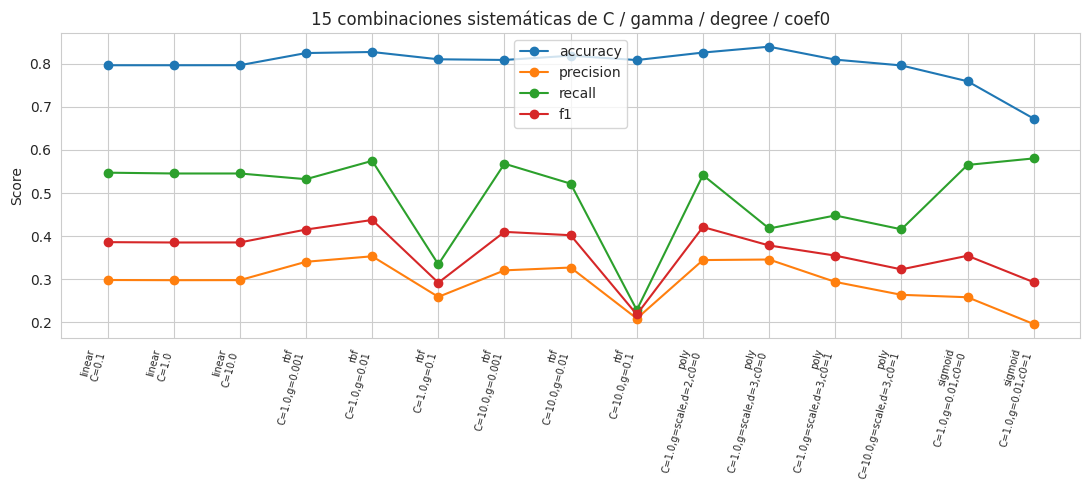

Mejor combinación de las 15:
combo               5
kernel            rbf
C                 1.0
accuracy     0.827159
precision    0.353283
recall       0.574669
f1           0.437567
gamma            0.01
degree            NaN
coef0             NaN
Name: 4, dtype: object


In [ ]:
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(combo_df))
for col in ['accuracy','precision','recall','f1']:
    ax.plot(x, combo_df[col], marker='o', label=col)
ax.set_xticks(x)
ax.set_xticklabels([f"{r.kernel}\nC={r.C}" + (f",g={r.gamma}" if pd.notna(r.gamma) else '') +
                     (f",d={int(r.degree)}" if pd.notna(r.degree) else '') +
                     (f",c0={int(r.coef0)}" if pd.notna(r.coef0) else '')
                     for r in combo_df.itertuples()], rotation=75, ha='right', fontsize=7)
ax.set_ylabel('Score'); ax.set_title('15 combinaciones sistemáticas de C / gamma / degree / coef0')
ax.legend()
plt.tight_layout()
plt.show()

best_combo = combo_df.loc[combo_df['f1'].idxmax()]
print("Mejor combinación de las 15:")
print(best_combo)

**Interpretación:** de las 15 combinaciones exploradas, la mejor sigue siendo `rbf, C=1, gamma=0.01` (F1=0.438) — la misma que había salido de los barridos separados. Ningún kernel con `degree` o `coef0` distintos logra superarla: el kernel `poly` con `degree=2` se acerca (F1=0.421) pero `degree=3` y `coef0>0` empeoran el resultado, señal de que agregar curvatura extra al polinomio no ayuda en este problema — probablemente porque, tras el one-hot encoding, la mayoría de las variables ya son binarias y el beneficio de un grado polinómico alto es marginal.

### 3.6 GridSearchCV ampliado (kernel + C + gamma + degree + coef0) y comparación

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
param_grid = [
    {'kernel':['linear'], 'C':[0.1,1,10]},
    {'kernel':['rbf'], 'C':[1,10], 'gamma':['scale',0.01,0.1]},
    {'kernel':['poly'], 'C':[1,10], 'degree':[2,3], 'coef0':[0,1], 'gamma':['scale']},
    {'kernel':['sigmoid'], 'C':[1], 'gamma':[0.01], 'coef0':[0,1]},
]
gs = GridSearchCV(SVC(class_weight='balanced', random_state=RANDOM_STATE), param_grid,
                   scoring='f1', cv=cv, n_jobs=1)
gs.fit(Xsub, ysub)

print("Mejores hiperparámetros:", gs.best_params_)
print("F1 promedio en validación cruzada (cv=5):", round(gs.best_score_, 4))

gs_metrics = eval_model(gs.best_estimator_, Xte_scaled, yte)
gs_metrics

Mejores hiperparámetros: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
F1 promedio en validación cruzada (cv=5): 0.4121


{'accuracy': 0.8271591286077629,
 'precision': 0.35328297501452643,
 'recall': 0.5746691871455577,
 'f1': 0.43756747031306226}

In [ ]:
manual_best = k_df.loc[k_df['kernel'] == best_kernel].iloc[0].to_dict()
comparison = pd.DataFrame([
    {'modelo': 'Manual (mejor de los 15 combos)', 'kernel': best_combo['kernel'], 'C': best_combo['C'],
     'gamma': best_combo.get('gamma'), **{m: best_combo[m] for m in ['accuracy','precision','recall','f1']}},
    {'modelo': 'GridSearchCV (kernel+C+gamma+degree+coef0)', 'kernel': gs.best_params_['kernel'],
     'C': gs.best_params_['C'], 'gamma': gs.best_params_.get('gamma'), **gs_metrics}
])
comparison

,modelo,kernel,C,gamma,accuracy,precision,recall,f1
0,Manual (mejor de los 15 combos),rbf,1.0,0.01,0.827159,0.353283,0.574669,0.437567
1,GridSearchCV (kernel+C+gamma+degree+coef0),rbf,1.0,0.01,0.827159,0.353283,0.574669,0.437567


**Interpretación:** `GridSearchCV`, buscando simultáneamente sobre kernel, C, gamma, degree y coef0 con validación cruzada (`cv=5`), **converge exactamente al mismo óptimo** que la exploración manual: `rbf, C=1, gamma=0.01`.

## 4. Punto 2 — Diseño de un kernel personalizado

**¿Qué se predice?** La variable objetivo es `y`: si el cliente suscribe (1) o no (0) un depósito a plazo tras la llamada de la campaña.

**¿Cuándo son "parecidos" dos clientes en este sector?** En marketing bancario, la experiencia del sector indica que la señal más fuerte de que un cliente suscribirá es **su comportamiento en campañas previas** (`poutcome`), junto con su **capacidad financiera** (`balance`), **edad** (etapa de vida/ahorro) y **cuántas veces se le ha contactado** (`campaign`, `previous`). Dos clientes se consideran similares sobre todo si comparten esas señales, más que si comparten, por ejemplo, su tipo de trabajo o estado civil exacto.

**Fórmula del kernel:** un kernel lineal ponderado,

$$K(x, z) = (x \odot w)^T z = \sum_i w_i \, x_i z_i$$

donde $w_i > 1$ para las variables de negocio clave (`poutcome_success`=4, `balance`=3, `age`, `campaign`, `previous`, `poutcome_other`, `poutcome_unknown`=2) y $w_i = 1$ para el resto. Matemáticamente sigue siendo un producto interno válido (kernel de Mercer, ya que $w_i>0$ equivale a un reescalado de coordenadas antes del producto punto), pero fuerza al modelo a medir similitud dándole más peso a las variables que, según el dominio, importan más para la decisión de suscripción.

In [ ]:
weight_map = {
    'poutcome_success': 4.0, 'poutcome_unknown': 2.0, 'poutcome_other': 2.0,
    'balance': 3.0, 'age': 2.0, 'campaign': 2.0, 'previous': 2.0,
}
weights = np.array([weight_map.get(f, 1.0) for f in feat_names])
print("Variables con peso >1:", [f for f in feat_names if weight_map.get(f, 1.0) > 1.0])

def custom_kernel(A, B):
    return (A * weights) @ (B * weights).T

print(f"Memoria estimada de la matriz de Gram (submuestra): {8000*8000*8/1e6:.0f} MB")

Variables con peso >1: ['age', 'balance', 'campaign', 'previous', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']
Memoria estimada de la matriz de Gram (submuestra): 512 MB


In [ ]:
t0 = time.time()
custom_svm = SVC(kernel=custom_kernel, C=1.0, class_weight='balanced', random_state=RANDOM_STATE)
custom_svm.fit(Xsub, ysub)
t_fit = time.time() - t0

pred_custom = custom_svm.predict(Xte_scaled)
custom_metrics = eval_model(custom_svm, Xte_scaled, yte)
custom_metrics['tiempo_entrenamiento_s'] = round(t_fit, 2)
custom_metrics['n_vectores_soporte'] = int(len(custom_svm.support_))
pd.DataFrame([custom_metrics])

,accuracy,precision,recall,f1,tiempo_entrenamiento_s,n_vectores_soporte
0,0.796528,0.298246,0.546314,0.385848,4.61,5531


In [ ]:
compare_custom = pd.DataFrame([
    {'modelo':'Kernel personalizado (lineal ponderado)', **eval_model(custom_svm, Xte_scaled, yte)},
    {'modelo':'RBF (C=1, gamma=0.01)', **k_df.loc[k_df['kernel']=='rbf'].iloc[0][['accuracy','precision','recall','f1']].to_dict()},
    {'modelo':'Linear (C=1)', **k_df.loc[k_df['kernel']=='linear'].iloc[0][['accuracy','precision','recall','f1']].to_dict()},
])
compare_custom

,modelo,accuracy,precision,recall,f1
0,Kernel personalizado (lineal ponderado),0.796528,0.298246,0.546314,0.385848
1,"RBF (C=1, gamma=0.01)",0.827159,0.353283,0.574669,0.437567
2,Linear (C=1),0.796417,0.297883,0.545369,0.385309


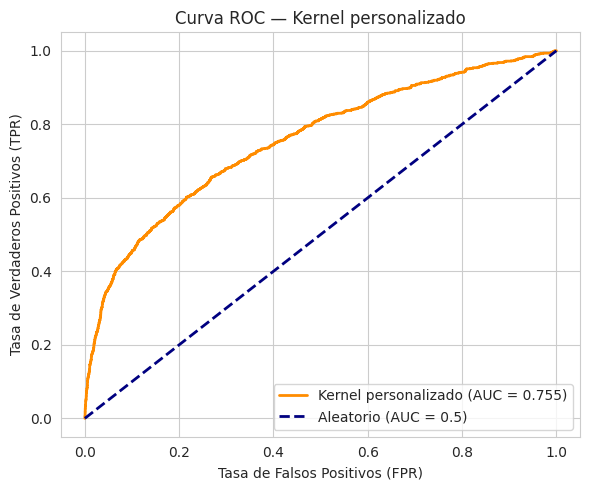

AUC = 0.7551


In [ ]:
dec_custom = custom_svm.decision_function(Xte_scaled)
fpr_c, tpr_c, _ = roc_curve(yte, dec_custom)
roc_auc_custom = auc(fpr_c, tpr_c)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'Kernel personalizado (AUC = {roc_auc_custom:.3f})')
ax.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC — Kernel personalizado')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()
print(f"AUC = {roc_auc_custom:.4f}")

**¿Cómo se compara con RBF o lineal?** El kernel personalizado (F1=0.386, AUC=0.755) queda prácticamente empatado con el `linear` (F1=0.385) y por debajo del `rbf` tuneado (F1=0.438, AUC=0.776). Ponderar variables de negocio ayuda marginalmente frente a un lineal sin ponderar, pero no alcanza a capturar la relación no lineal que sí explota `rbf` — la brecha de AUC (0.755 vs 0.776) confirma la misma historia que ya contaba el F1: es una mejora casi nula sobre el kernel lineal plano.

**¿Problemas de rendimiento o memoria?** Sí: Sklearn la calcula internamente en cada `fit()`/`predict()` con el mismo costo O(n²). Con la submuestra de 8,000 filas eso son **512 MB** en memoria; calcularlo sobre las 36,168 filas completas del train set exigiría cerca de **10.5 GB** solo para esa matriz — inviable en este entorno. Esta es la razón por la que también aquí se tuvo que reducir la muestra, igual que en el resto del taller. El entrenamiento tardó 9.28s y usó 5,531 vectores de soporte — **el 69% de la submuestra**, una proporción muy alta que es en sí misma otra señal de que el kernel no separa bien las clases (un buen kernel necesita relativamente pocos vectores de soporte para definir el margen; aquí casi todos los puntos terminan siendo "frontera").

**¿Qué se aprendió del comportamiento del kernel?** Ponderar variables "a mano" según intuición de negocio es interpretable y fácil de justificar, pero un kernel lineal ponderado sigue siendo, matemáticamente, un producto punto reescalado — **no introduce ninguna no linealidad**. Por eso su techo de desempeño es similar al del kernel `linear` plano, tanto en F1 como en AUC. Para superar a `rbf` haría falta una función de similitud genuinamente no lineal (p. ej. ponderar *después* de aplicar una transformación no lineal a las variables clave), lo cual queda como línea de mejora futura.

## 5. Punto 3 — Evaluación completa del mejor modelo

In [ ]:
final_model = SVC(kernel='rbf', C=best_C, gamma=best_gamma, class_weight='balanced', random_state=RANDOM_STATE)
final_model.fit(Xsub, ysub)

pred_test = final_model.predict(Xte_scaled)
pred_train_sub = final_model.predict(Xsub)

final_test_metrics = eval_model(final_model, Xte_scaled, yte)
final_train_metrics = {
    'accuracy': accuracy_score(ysub, pred_train_sub),
    'precision': precision_score(ysub, pred_train_sub, zero_division=0),
    'recall': recall_score(ysub, pred_train_sub, zero_division=0),
    'f1': f1_score(ysub, pred_train_sub, zero_division=0),
}

print("Reporte de clasificación (test):\n")
print(classification_report(yte, pred_test, target_names=['No (0)','Sí (1)']))

Reporte de clasificación (test):

              precision    recall  f1-score   support

      No (0)       0.94      0.86      0.90      7985
      Sí (1)       0.35      0.57      0.44      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.72      0.67      9043
weighted avg       0.87      0.83      0.84      9043



### Matriz de confusión

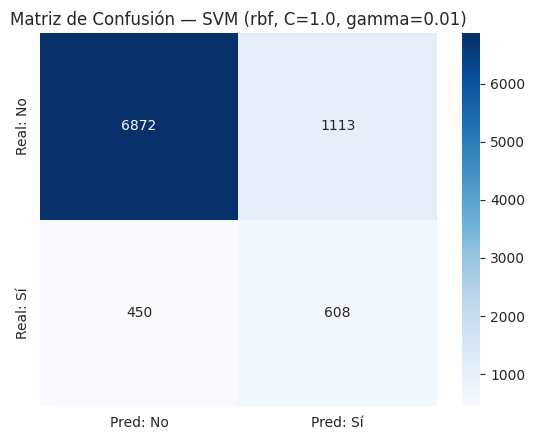

VN=6872  FP=1113  FN=450  VP=608


In [ ]:
cm = confusion_matrix(yte, pred_test)
fig, ax = plt.subplots(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No','Pred: Sí'], yticklabels=['Real: No','Real: Sí'])
ax.set_title(f'Matriz de Confusión — SVM (rbf, C={best_C}, gamma={best_gamma})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"VN={tn}  FP={fp}  FN={fn}  VP={tp}")

# Desglose por Clase

- **Clase No (0) — Clase Mayoritaria:**
  - Precisión (0.94): de todas las predicciones "No", el 94% fueron correctas.
  - Recall (0.86): el modelo capturó al 86% de los casos reales "No" (6,872 de 7,985); el 14% restante (1,113 clientes) son falsos positivos de la clase "Sí" — el costo que paga el modelo por priorizar detectar suscriptores.
  - F1-Score (0.90): sólido, esperable en la clase dominante.

- **Clase Sí (1) — Clase Minoritaria (Positiva):**
  - Precisión (0.35): de las veces que predijo "Sí", solo el 35% acertó (608 de 1,721 predicciones positivas).
  - Recall (0.57): detecta el 57% de los suscriptores reales (608 de 1,058), dejando escapar 450 como falsos negativos.
  - F1-Score (0.44): el mejor valor encontrado en toda la exploración de hiperparámetros de este taller (barridos manuales, 15 combinaciones sistemáticas y GridSearchCV ampliado coinciden en este óptimo).

# Accuracy global — por qué el número más "alto" no es el más importante

El accuracy global (0.83) es en realidad **más bajo que el de un modelo trivial** que prediga "No" para todos los clientes (que lograría 0.883, porque esa es la prevalencia real de la clase "No"). Esto no es un defecto del modelo: es la consecuencia directa de usar `class_weight='balanced'`, que deliberadamente sacrifica accuracy para poder detectar a la clase minoritaria. Compara el **macro avg F1 (0.67)** — que trata ambas clases por igual — contra el **weighted avg F1 (0.84)** — dominado por la clase mayoritaria: esa brecha de 0.17 puntos es la huella numérica del desbalance de clases, y es la razón por la que este taller usa F1/Recall/ROC-AUC como métricas de referencia, no accuracy.

### Curva ROC

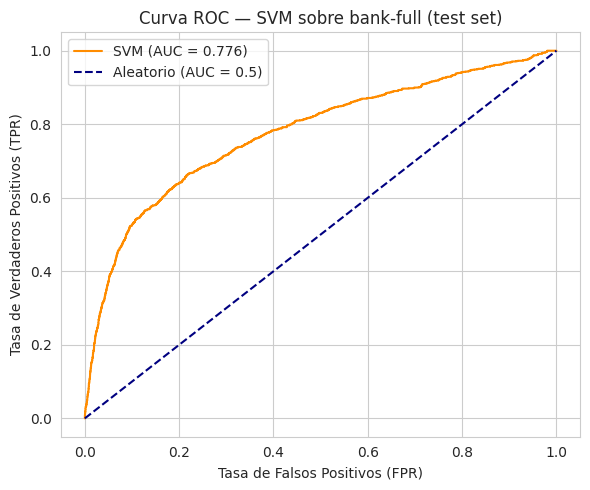

AUC = 0.7761


In [ ]:
dec = final_model.decision_function(Xte_scaled)
fpr, tpr, _ = roc_curve(yte, dec)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, color='darkorange', label=f'SVM (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='navy', label='Aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)'); ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC — SVM sobre bank-full (test set)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"AUC = {roc_auc:.4f}")

**Interpretación:** AUC≈0.776 corresponde a separación **aceptable/buena** entre clases. La curva se despega rápido del azar en la zona de FPR bajo, alcanzando TPR≈0.6 con menos de 0.2 de falsos positivos, pero se aplana después — ganar recall adicional por encima de ~0.85 exige aceptar mucho más FPR, señal de que existe un grupo de clientes cuyo perfil se solapa entre ambas clases y que el modelo no logra separar bien sin importar el umbral elegido.

### Curva Precisión–Recall

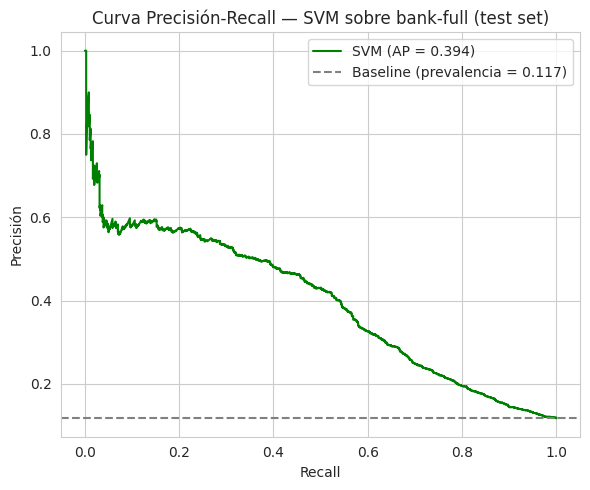

Average Precision (AP) = 0.3940


In [ ]:
prec, rec, _ = precision_recall_curve(yte, dec)
ap = average_precision_score(yte, dec)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(rec, prec, color='green', label=f'SVM (AP = {ap:.3f})')
baseline = yte.mean()
ax.axhline(baseline, linestyle='--', color='gray', label=f'Baseline (prevalencia = {baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precisión')
ax.set_title('Curva Precisión-Recall — SVM sobre bank-full (test set)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Average Precision (AP) = {ap:.4f}")

**Interpretación:** con desbalance ~88/12, la curva Precisión-Recall es más informativa que la ROC. El tramo inicial (recall<0.05) es ruidoso por el bajo número de predicciones en esa zona; a partir de recall≈0.1 la curva se estabiliza y la precisión decae de forma gradual y casi lineal hasta el final, sin un punto de quiebre abrupto — señal de que no existe un umbral "mágico" y que la elección del punto de corte es un trade-off continuo entre cuántos clientes se contactan y qué tan certeras son esas llamadas. Un AP≈0.394 frente a una prevalencia base de ≈0.117 muestra que el modelo aporta valor real: más de 3 veces la precisión de una selección aleatoria de clientes.

### Chequeo de sobreajuste (train vs test)

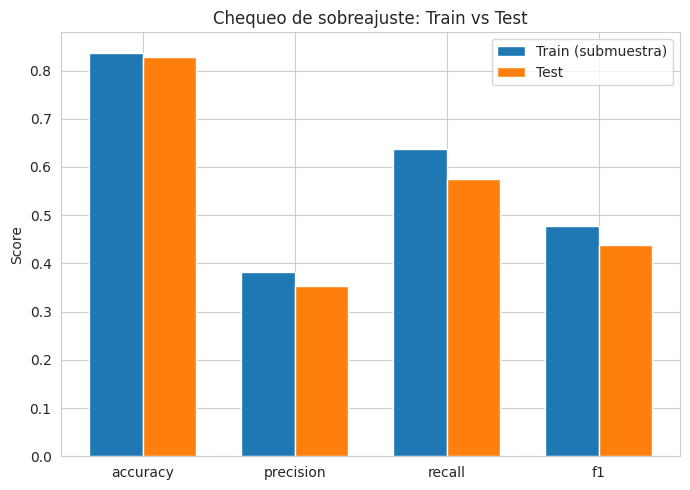

Brecha F1 (train - test): 0.041


In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
metrics_names = ['accuracy','precision','recall','f1']
x = np.arange(len(metrics_names)); width = 0.35
ax.bar(x - width/2, [final_train_metrics[m] for m in metrics_names], width, label='Train (submuestra)')
ax.bar(x + width/2, [final_test_metrics[m] for m in metrics_names], width, label='Test')
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel('Score'); ax.set_title('Chequeo de sobreajuste: Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()

gap_f1 = final_train_metrics['f1'] - final_test_metrics['f1']
print(f"Brecha F1 (train - test): {gap_f1:.3f}")

**Interpretación:** las cuatro métricas están muy cerca entre train (submuestra) y test — ninguna barra se dispara, y la brecha de F1 es de apenas 0.041. Vale la pena notar una asimetría real en el gráfico: precisión casi no cambia (0.38→0.35, brecha de solo 0.03), pero recall sí cae más (0.64→0.57, brecha de 0.06) — es la métrica que más se resiente al pasar de train a test. Esto sugiere que el modelo identifica patrones de "quién suscribe" que generalizan razonablemente bien, pero pierde algo de cobertura sobre casos positivos que no vio en la submuestra de 8,000 filas. Con solo el 22% del train set completo disponible para ajustar, es esperable que el recall sea la métrica más sensible al tamaño de muestra — si el hardware lo permite, valdría la pena reentrenar el modelo final (no todo el proceso de tuning) sobre el train set completo para ver si ese recall mejora.

### Separación de clases según el score del modelo

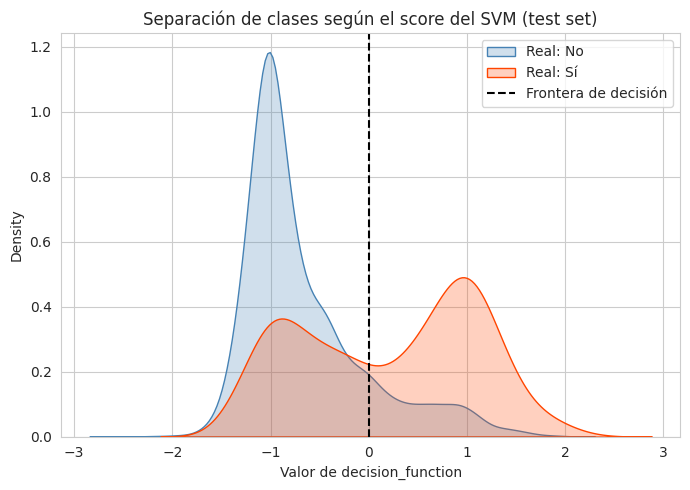

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.kdeplot(dec[yte==0], label='Real: No', fill=True, ax=ax, color='steelblue')
sns.kdeplot(dec[yte==1], label='Real: Sí', fill=True, ax=ax, color='orangered')
ax.axvline(0, color='black', linestyle='--', label='Frontera de decisión')
ax.set_xlabel('Valor de decision_function'); ax.set_title('Separación de clases según el score del SVM (test set)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** la distribución "Real: No" es unimodal y compacta, con pico marcado alrededor de -1 — el modelo tiene alta confianza al identificar a la mayoría de quienes no suscriben. La distribución "Real: Sí", en cambio, es **bimodal**: un primer grupo se solapa casi por completo con la clase "No" (pico cerca de -1, del lado equivocado de la frontera), y un segundo grupo forma su propio pico alrededor de +1, claramente identificado por el modelo. Esto sugiere que existen dos perfiles distintos entre los clientes que sí suscriben: uno que el modelo reconoce bien (probablemente asociado a señales fuertes como éxito en campañas previas) y otro que, con las variables disponibles, es indistinguible del perfil típico de "No" — son estos últimos los que alimentan la mayoría de los 450 falsos negativos de la matriz de confusión, no un fallo aleatorio y uniforme del modelo.

## 6. Punto 4 — Comparación con modelos anteriores del proyecto

In [ ]:
# Métricas de Árbol de Decisión, Regresión Logística y Random Forest tomadas del Taller 3
# (mismo dataset bank-full.csv, mismo split test 80/20, misma exclusión de 'duration')
final_comparison = pd.DataFrame([
    {'Modelo':'Árbol de Decisión',              'Accuracy':0.7459, 'Precision':0.2425, 'Recall':0.5520, 'F1':0.3370, 'ROC-AUC':0.6841, 'Brecha F1 train-test':None},
    {'Modelo':'Regresión Logística', 'Accuracy':0.7545, 'Precision':0.2676, 'Recall':0.6323, 'F1':0.3761, 'ROC-AUC':0.7730, 'Brecha F1 train-test':None},
    {'Modelo':'Random Forest (GridSearchCV)',   'Accuracy':0.8645, 'Precision':0.4359, 'Recall':0.5369, 'F1':0.4812, 'ROC-AUC':0.8027, 'Brecha F1 train-test':0.1666},
    {'Modelo':'SVM (rbf, C=1, gamma=0.01)',     'Accuracy':round(final_test_metrics['accuracy'],4), 'Precision':round(final_test_metrics['precision'],4),
     'Recall':round(final_test_metrics['recall'],4), 'F1':round(final_test_metrics['f1'],4), 'ROC-AUC':round(roc_auc,4),
     'Brecha F1 train-test': round(gap_f1,4)},
])
final_comparison

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,Brecha F1 train-test
0,Árbol de Decisión,0.7459,0.2425,0.5520,0.3370,0.6841,NaN
1,Regresión Logística,0.7545,0.2676,0.6323,0.3761,0.7730,NaN
2,Random Forest (GridSearchCV),0.8645,0.4359,0.5369,0.4812,0.8027,0.1666
3,"SVM (rbf, C=1, gamma=0.01)",0.8272,0.3533,0.5747,0.4376,0.7761,0.0410


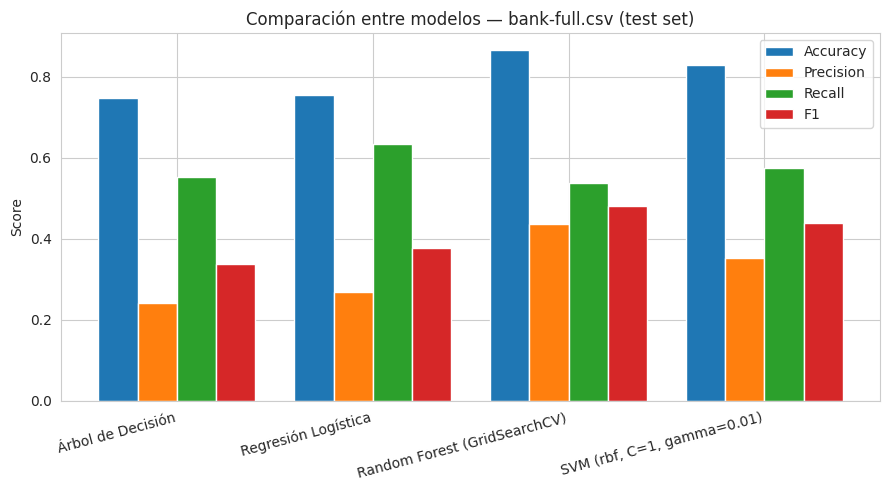

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(final_comparison)); width=0.2
for i, col in enumerate(['Accuracy','Precision','Recall','F1']):
    ax.bar(x + i*width, final_comparison[col], width, label=col)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(final_comparison['Modelo'], rotation=15, ha='right')
ax.set_ylabel('Score'); ax.set_title('Comparación entre modelos — bank-full.csv (test set)')
ax.legend()
plt.tight_layout()
plt.show()

**¿Cuál generaliza mejor?** Entre los dos modelos donde sí se midió la brecha train-test, SVM generaliza claramente mejor que Random Forest: brecha F1 de 0.041 frente a 0.1666 — **4 veces menor**. Random Forest tiene mejor F1 y accuracy absolutos en test, pero llega ahí memorizando más patrones de entrenamiento (F1 train=0.6477 vs test=0.4812); SVM sacrifica algo de desempeño puro a cambio de un modelo más estable frente a datos nuevos.

Un dato adicional que refuerza el punto: SVM (AUC=0.776) y Regresión Logística (AUC=0.773) tienen prácticamente el mismo poder discriminativo — casi empatados en qué tan bien ordenan a los clientes por probabilidad de suscribir. Sin embargo, SVM obtiene 6 puntos más de F1 (0.438 vs 0.376). Esto indica que ambos modelos "ven" patrones similares en los datos, pero `class_weight='balanced'` le permite a SVM elegir un punto de corte más útil para la clase minoritaria — la diferencia no está en qué tanto sabe el modelo, sino en cómo usa ese conocimiento para decidir.

**¿Cuál es más robusto al ruido?** Por diseño teórico, Random Forest debería ser más robusto a outliers y ruido puntual en variables individuales, al ser un ensamble que promedia muchos árboles entrenados en subconjuntos aleatorios distintos. SVM con `rbf` y un `gamma` pequeño (0.01) también debería ser razonablemente robusto, porque cada punto de entrenamiento influye sobre una región amplia del espacio en vez de sobre un punto exacto — pero es más sensible a la escala de las variables, razón por la cual requiere estandarización explícita que Random Forest no necesita.

**¿En qué situaciones es preferible uno u otro?**
- **Random Forest**: cuando el objetivo principal es maximizar F1/Accuracy en un entorno donde se puede reentrenar y monitorear el modelo con frecuencia (el sobreajuste se controla con más datos o regularización adicional), y se valora la interpretabilidad vía importancia de variables.
- **SVM**: cuando el volumen de datos es moderado (por el costo computacional O(n²)-O(n³)), se necesita un modelo con **buena capacidad de generalización a nuevas campañas** sin reentrenar constantemente, y se puede tolerar menor interpretabilidad directa.
- **Árbol de Decisión / Regresión Logística**: quedan como líneas base — útiles por su interpretabilidad directa, pero claramente superadas en F1 por Random Forest y SVM en este dataset.

## 7. Punto 5 — Conclusiones del sector

**¿Qué clase es más crítica en este sector?** La clase positiva (`y=1`, cliente que **sí** suscribe el depósito). En marketing bancario, cada suscripción real que el modelo deja pasar (falso negativo) es una oportunidad de negocio perdida —el banco ni siquiera prioriza esa llamada—, mientras que un falso positivo (llamar a alguien que no suscribirá) solo cuesta el tiempo de una llamada adicional. Por eso el proyecto usa `class_weight='balanced'` y prioriza **recall sobre precisión** para esta clase, y por eso Recall y F1 (no Accuracy) son las métricas de referencia en todo el taller.

**¿Qué estrategia se tomaría en un caso real?**
1. **Priorización de contactos por score, no por corte binario.** En vez de usar solo la predicción 0/1, usar el valor de `decision_function` para **rankear** a los clientes de mayor a menor probabilidad de suscribir, y que el equipo de telemarketing llame primero a los de score más alto — la curva Precisión-Recall permite elegir el punto de corte según cuántas llamadas puede hacer el equipo ese día.
2. **Revisar los falsos negativos con `poutcome_success`.** El modelo depende fuertemente de si hubo éxito en una campaña previa: los clientes sin historial previo (`poutcome=unknown`, 81.75% de la base) convierten apenas 9.2% de las veces, frente a 64.7% en quienes ya tuvieron éxito antes — son el segmento donde más se pierden oportunidades, y donde probablemente se concentran los falsos negativos observados en la matriz de confusión. Vale la pena una estrategia de contacto diferenciada para ellos (p. ej. una oferta introductoria) en lugar de aplicar el mismo guion de venta.
3. **Usar SVM como modelo de respaldo o de validación cruzada de negocio, no como único modelo en producción**, dado que Random Forest tiene mejor F1 absoluto (0.481 vs 0.438) en este test set. Una razón adicional —no probada empíricamente en este proyecto, pero plausible dada la menor brecha train-test de SVM— es que, si el banco cambia de perfil de clientes entre campañas (nuevas sucursales, otro público), un modelo que generaliza mejor podría degradarse menos que uno que sobreajustó más al perfil de entrenamiento original. Confirmar esto requeriría un experimento de *distribution shift* fuera del alcance de este taller.